#  Import Libraries and tools

In [1]:
import os
import numpy as np 
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

# Load Datasets

In [23]:
train_dir = 'Training'
test_dir = 'Testing'

train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

# Data Visualization

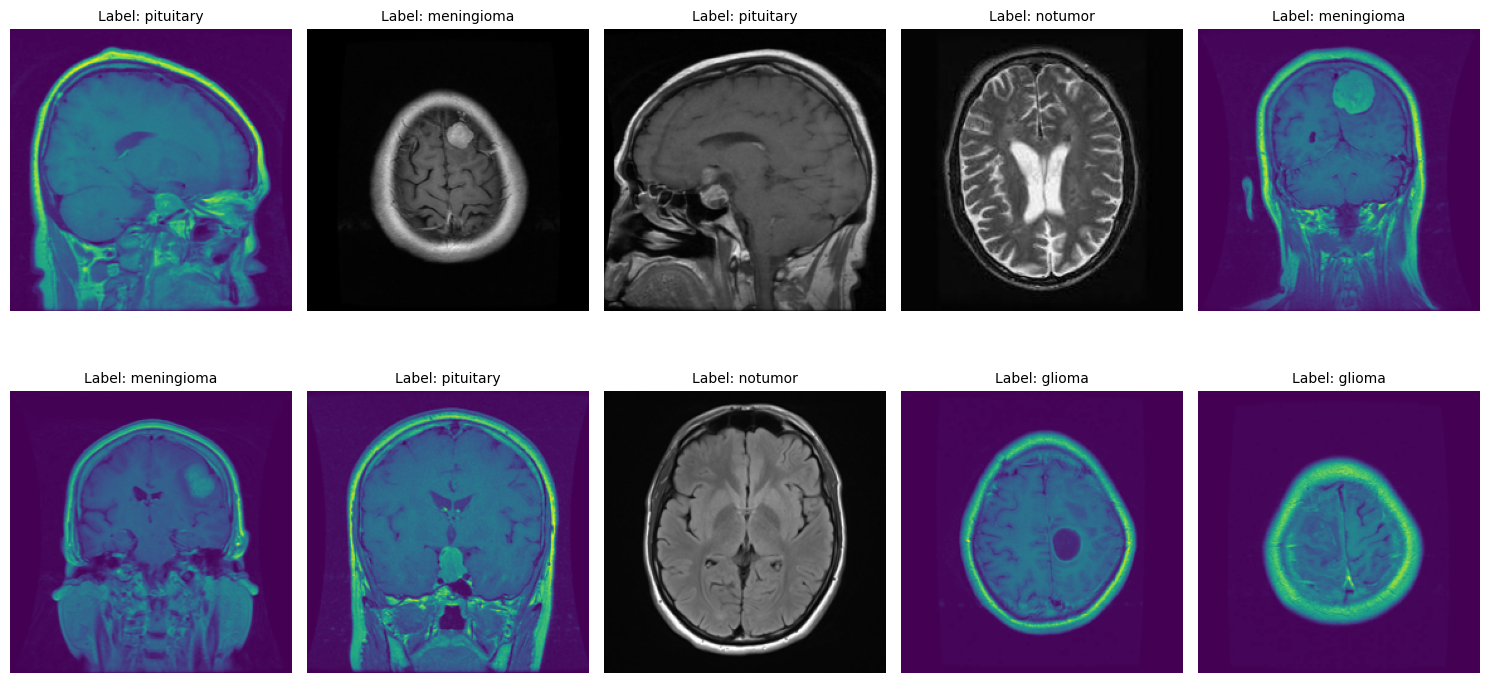

In [24]:
import matplotlib.pyplot as plt
from PIL import Image
import os

random_indices = random.sample(range(len(train_paths)), 10)

fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))  

    axes[i].imshow(img)
    axes[i].axis('off')  
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()

# Image Preprocessing (Augmentation Functions)

In [25]:
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  
    image = np.array(image) / 255.0  
    return image

def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

def encode_label(labels):
    unique_labels = os.listdir(train_dir)  
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  
            yield batch_images, batch_labels  

# MODEL:


## WE ARE USING VGG16 FOR TRANSFER LEARNING.
* The model is built using VGG16, a pre-trained Convolutional Neural Network (CNN) widely used for image classification. It has been trained on the ImageNet dataset, which contains over 1.4 million images across 1,000 categories. In this project, VGG16 is leveraged through transfer learning to classify MRI images into different brain tumor types.

* First, the VGG16 model is initialized with input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, and weights='imagenet'. The input shape ensures compatibility with our MRI images, resized to 128×128 pixels. Setting include_top=False removes the original classification head of the VGG16 model, allowing us to add custom layers suited to our tumor classification task. Using weights='imagenet' helps the model start with learned visual features from a large-scale dataset.

* Next, all layers in the VGG16 base model are set to non-trainable using a loop: for layer in base_model.layers: layer.trainable = False. This prevents the base layers from updating during initial training and preserves the powerful feature extraction capabilities learned from ImageNet.

* Then, the last three layers of the VGG16 model are set to trainable using:
base_model.layers[-2].trainable = True,
base_model.layers[-3].trainable = True,
base_model.layers[-4].trainable = True.
This fine-tuning allows the model to adapt to the specific features of brain MRI images without overfitting.

* After that, a Sequential model is created and the base VGG16 model is added to it using model.add(base_model), forming the backbone of our custom classifier.

* Next, a Flatten() layer is added to reshape the 3D output of the convolutional base into a 1D vector. This prepares the data for processing by dense (fully connected) layers.

* Then, a Dropout(0.3) layer is added to reduce overfitting by randomly deactivating 30% of the neurons during training.

* After that, a Dense layer with 128 neurons and the ReLU activation function is added using model.add(Dense(128, activation='relu')). This allows the model to learn complex patterns in the data.

* Next, another Dropout(0.2) layer is added to further improve regularization and generalization.

* Finally, the output layer is added using model.add(Dense(len(unique_labels), activation='softmax')). This layer uses the softmax activation function to provide a probability distribution across the tumor classes, enabling accurate classification of the input MRI image.

In [26]:
IMAGE_SIZE = 128  
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

for layer in base_model.layers:
    layer.trainable = False

base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  
model.add(base_model) 
model.add(Flatten())  
model.add(Dropout(0.3)) 
model.add(Dense(128, activation='relu'))  
model.add(Dropout(0.2))  
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

batch_size = 20
steps = int(len(train_paths) / batch_size)  
epochs = 5

history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

Epoch 1/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 217s 753ms/step - loss: 0.6571 - sparse_categorical_accuracy: 0.7380
Epoch 2/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 212s 744ms/step - loss: 0.2667 - sparse_categorical_accuracy: 0.9024
Epoch 3/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 208s 729ms/step - loss: 0.1699 - sparse_categorical_accuracy: 0.9342
Epoch 4/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1693s 6s/step - loss: 0.1352 - sparse_categorical_accuracy: 0.9504
Epoch 5/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 212s 744ms/step - loss: 0.0922 - sparse_categorical_accuracy: 0.9704


# Train and Val Plots


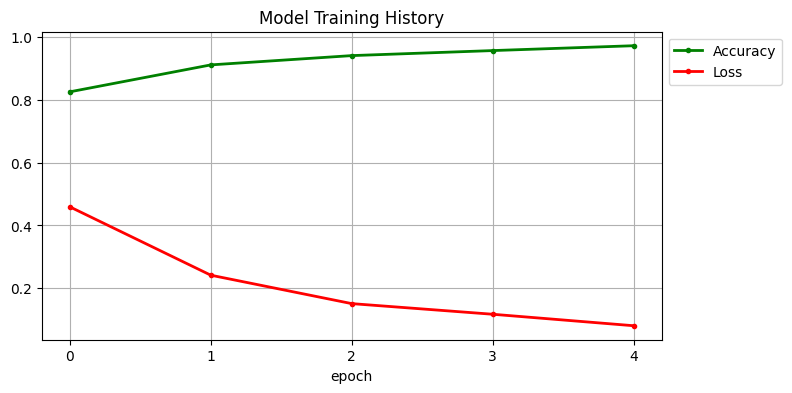

In [27]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

# Model Classification Report


In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

test_images = open_images(test_paths)  
test_labels_encoded = encode_label(test_labels)  

test_predictions = model.predict(test_images)

print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

41/41 ━━━━━━━━━━━━━━━━━━━━ 36s 879ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       300
           1       0.96      0.78      0.86       306
           2       0.95      1.00      0.98       405
           3       0.96      0.98      0.97       300

    accuracy                           0.94      1311
   macro avg       0.94      0.94      0.93      1311
weighted avg       0.94      0.94      0.94      1311



# Model Confusion Plot


Confusion Matrix:
[[294   6   0   0]
 [ 34 240  19  13]
 [  0   0 405   0]
 [  3   3   1 293]]


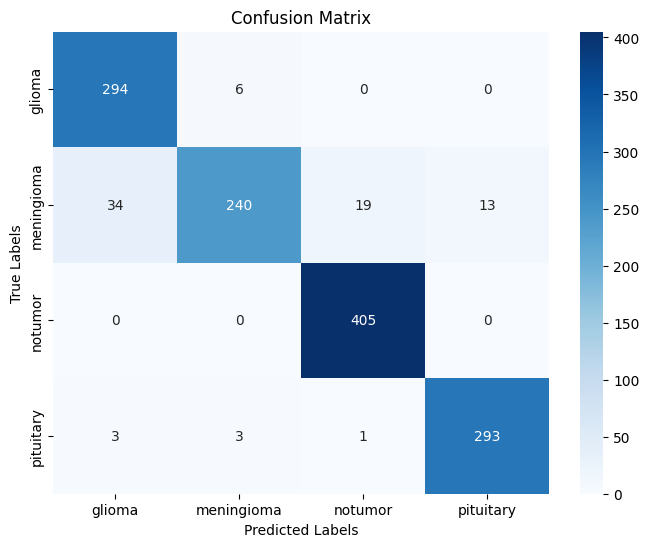

In [29]:
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Roc Curve Plot


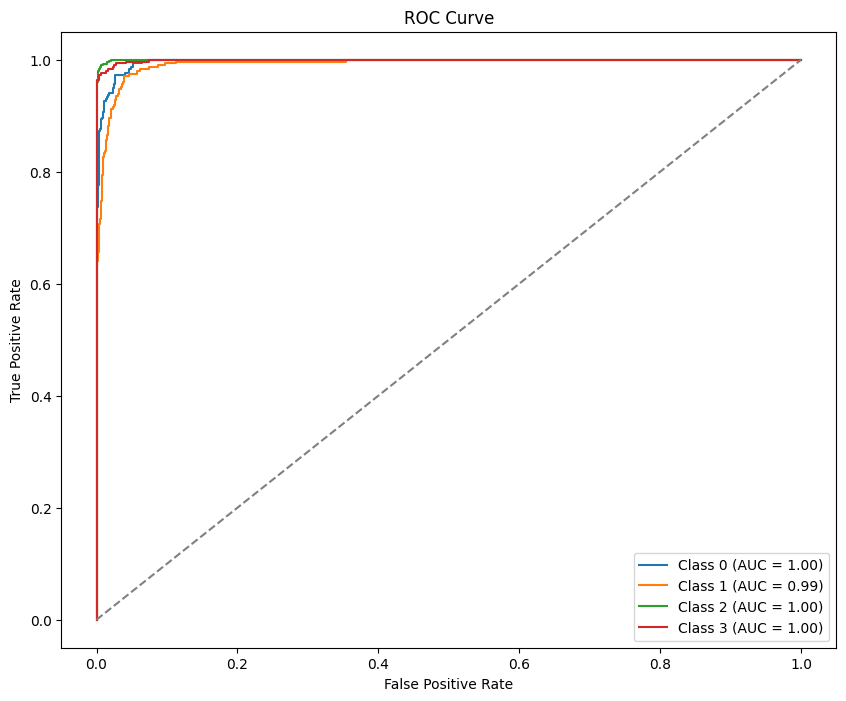

In [30]:
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  

fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# Save & Load Model


In [31]:
model.save('model.h5')

In [32]:
from tensorflow.keras.models import load_model
model = load_model('model.h5')

# MRI Tumor Detection System


In [33]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0 
        img_array = np.expand_dims(img_array, axis=0)  

        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        unique_labels = sorted(os.listdir(train_dir))

        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))

# Testing 1:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step


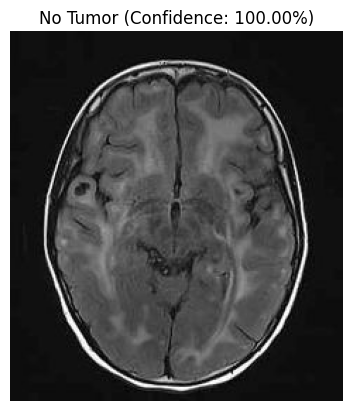

In [34]:
image_path = 'Testing/notumor/Te-no_0019.jpg' 
detect_and_display(image_path, model)

# Testing 2:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


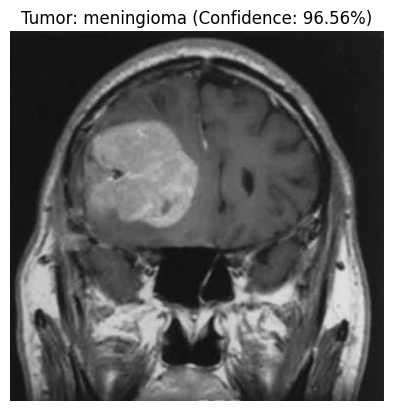

In [35]:
image_path = 'Testing/meningioma/Te-me_0021.jpg'  
detect_and_display(image_path, model)

# Testing 3:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


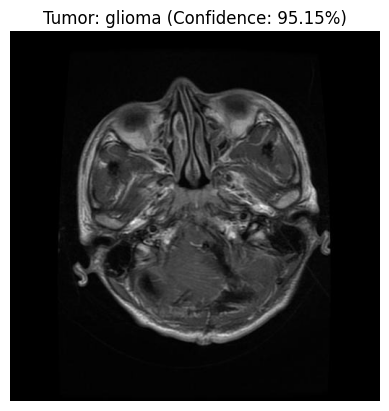

In [36]:
image_path = 'Testing/glioma/Te-gl_0024.jpg'  
detect_and_display(image_path, model)

# Testing 4:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


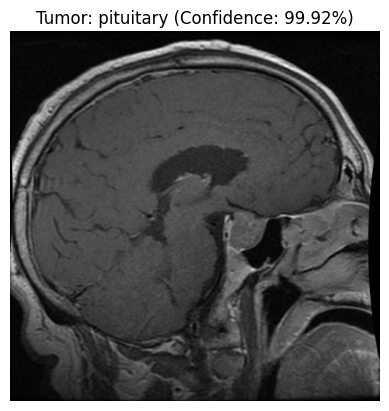

In [37]:
image_path = 'Testing/pituitary/Te-pi_0243.jpg'  
detect_and_display(image_path, model)